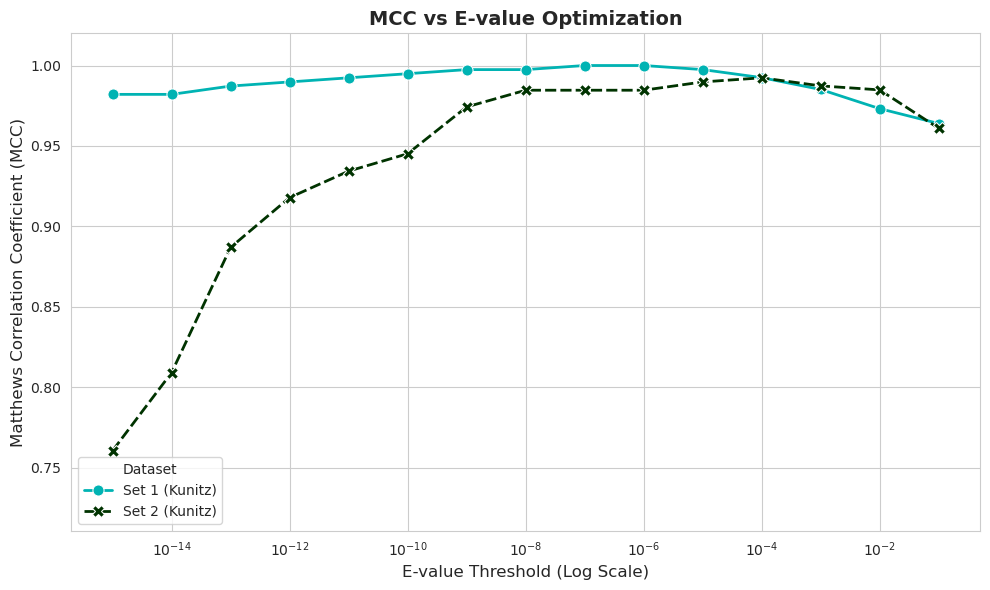

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

def create_mcc_visualization(file1_path, file2_path):
    """
    Parses .performance files and creates a comparative MCC vs E-value plot.
    """
    def parse_performance_file(filepath, subset_name):
        data = []
        with open(filepath, 'r') as f:
            for line in f:
                # Use regex to find the numbers following 'TH:' and 'MCC'
                th_match = re.search(r'TH:\s+([0-9.eE+-]+)', line)
                mcc_match = re.search(r'MCC\s+([0-9.eE+-]+)', line)
                
                if th_match and mcc_match:
                    data.append({
                        'E-value': float(th_match.group(1)),
                        'MCC': float(mcc_match.group(1)),
                        'Subset': subset_name
                    })
        return pd.DataFrame(data)

    # 1. Load and parse the specific performance files
    # kunitz_set_1.performance reaches MCC 1.0 at 1e-06
    df1 = parse_performance_file(file1_path, 'Set 1 (Kunitz)')
    # kunitz_set_2.performance reaches peak MCC 0.9923 at 0.0001
    df2 = parse_performance_file(file2_path, 'Set 2 (Kunitz)')

    # 2. Combine datasets
    combined_df = pd.concat([df1, df2], ignore_index=True)

    # 3. Visualization Setup
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    
    # Matching preferred color scheme
            
    custom_palette = {'Set 1 (Kunitz)': '#00b3b3', 'Set 2 (Kunitz)': '#003300', 'alpha':0.7}

    plot = sns.lineplot(
        data=combined_df,
        x='E-value',
        y='MCC',
        hue='Subset',
        style='Subset',
        markers=True,
        markersize=8,
        palette=custom_palette,
        linewidth=2
    )

    # 4. Refine Axes and Labels
    plt.xscale('log') # E-values range from 0.1 to 1e-15
    plt.xlabel('E-value Threshold (Log Scale)', fontsize=12)
    plt.ylabel('Matthews Correlation Coefficient (MCC)', fontsize=12)
    plt.title('MCC vs E-value Optimization', fontsize=14, fontweight='bold')
    
    # Setting Y-axis limits to focus on high-performance range
    plt.ylim(combined_df['MCC'].min() - 0.05, 1.02)
    
    plt.legend(title='Dataset', loc='lower left')
    plt.tight_layout()

    # 5. Save and Show
    plt.savefig('MCCvsEvalue_Optimization.png', dpi=300)
    plt.show()

create_mcc_visualization('kunitz_set_1.performance', 'kunitz_set_2.performance')